## Key Findings

1. **Revenue Trend**: [Insert finding from Cell 7]
2. **Geographic Focus**: United Kingdom dominates with ~90% of revenue
3. **Product Performance**: [Top 3 products from Cell 9]
4. **Customer Base**: [Customer insights from Cell 10]
5. **Seasonality**: [Pattern observations]

Customer Statistics:
            Orders        Revenue       Quantity  AvgOrderValue
count  4338.000000    4338.000000    4338.000000    4338.000000
mean     90.523974    2048.692230    1187.644767      68.381596
std     225.506929    8985.229676    5043.619620    1467.918294
min       1.000000       3.750000       1.000000       2.136970
25%      17.000000     306.482500     159.000000      12.393196
50%      41.000000     668.570000     378.000000      17.755000
75%      98.000000    1660.597500     989.750000      24.878950
max    7676.000000  280206.020000  196915.000000   77183.600000

Total unique customers: 4,338
Average orders per customer: 90.5
Average revenue per customer: £2048.69


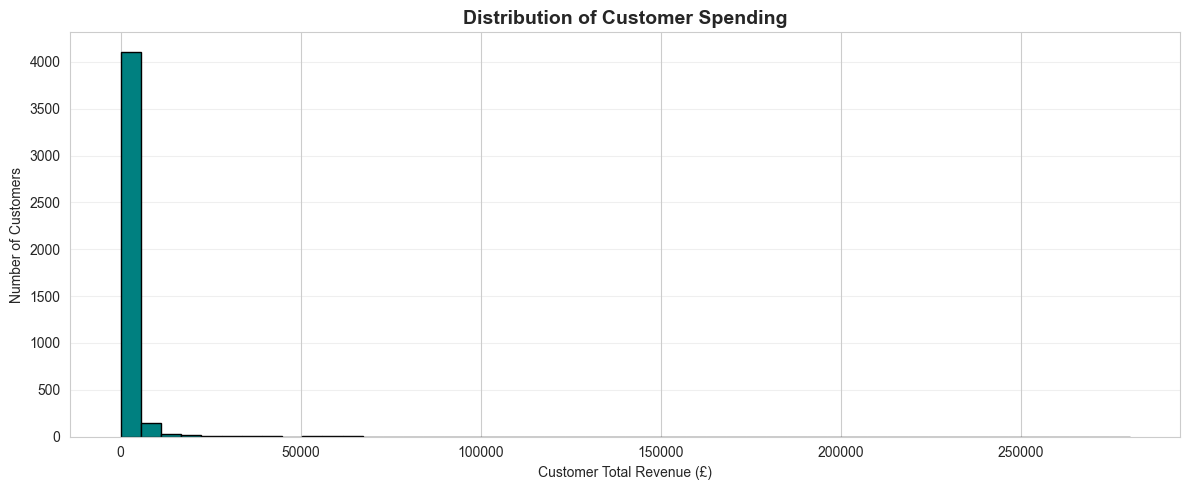

In [13]:
# Customer metrics
customer_stats = df_clean.groupby('Customer ID').agg({
    'Invoice': 'count',
    'Revenue': 'sum',
    'Quantity': 'sum'
}).rename(columns={'Invoice': 'Orders'})

customer_stats['AvgOrderValue'] = customer_stats['Revenue'] / customer_stats['Orders']

print("Customer Statistics:")
print(customer_stats.describe())

print(f"\nTotal unique customers: {len(customer_stats):,}")
print(f"Average orders per customer: {customer_stats['Orders'].mean():.1f}")
print(f"Average revenue per customer: £{customer_stats['Revenue'].mean():.2f}")

# Distribution of customer spending
plt.figure(figsize=(12, 5))
plt.hist(customer_stats['Revenue'], bins=50, color='teal', edgecolor='black')
plt.xlabel('Customer Total Revenue (£)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Spending', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Top 10 Products by Quantity:
  StockCode                         Description  Quantity    Revenue
0     23843         PAPER CRAFT , LITTLE BIRDIE     80995  168469.60
1     23166      MEDIUM CERAMIC TOP STORAGE JAR     77916   81416.73
2     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319   13558.41
3    85099B             JUMBO BAG RED RETROSPOT     46078   85040.54
4    85123A  WHITE HANGING HEART T-LIGHT HOLDER     36706  100392.10
5     84879       ASSORTED COLOUR BIRD ORNAMENT     35263   56413.03
6     21212     PACK OF 72 RETROSPOT CAKE CASES     33670   16381.88
7     22197                      POPCORN HOLDER     30919   23417.51
8     23084                  RABBIT NIGHT LIGHT     27153   51251.24
9     22492             MINI PAINT SET VINTAGE      26076   16039.24


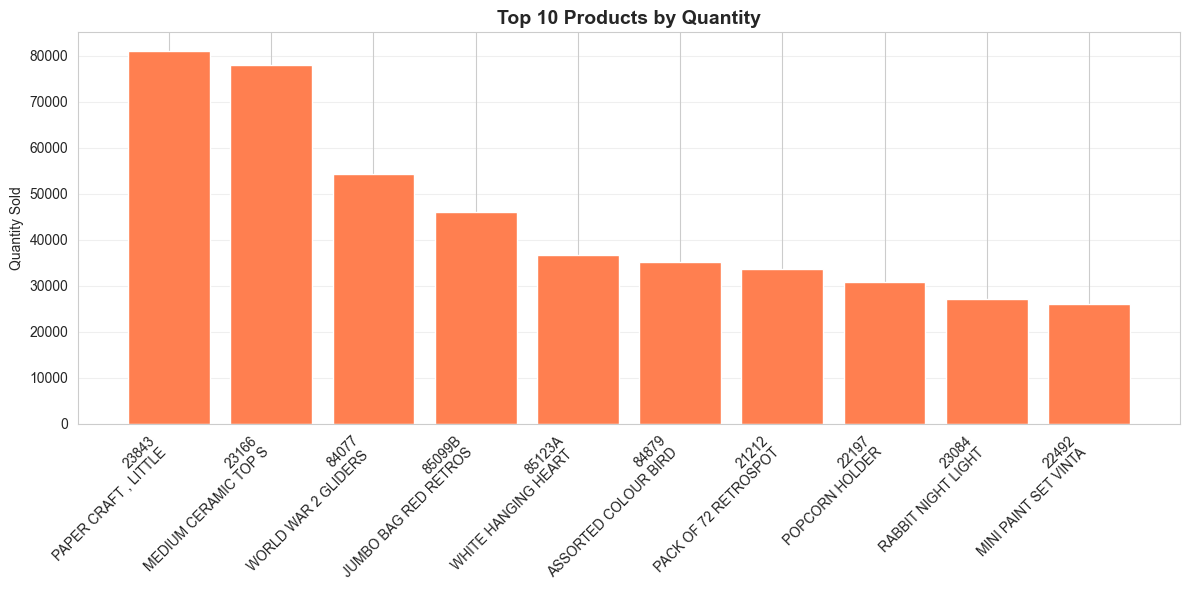

In [12]:
# Top 10 products
top_products = df_clean.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'Revenue': 'sum'
}).sort_values('Quantity', ascending=False).head(10).reset_index()

print("Top 10 Products by Quantity:")
print(top_products)

# Chart
plt.figure(figsize=(12, 6))
product_labels = [f"{row['StockCode']}\n{row['Description'][:20]}" for _, row in top_products.iterrows()]
plt.bar(range(len(top_products)), top_products['Quantity'].values, color='coral')
plt.xticks(range(len(top_products)), product_labels, rotation=45, ha='right')
plt.ylabel('Quantity Sold')
plt.title('Top 10 Products by Quantity', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Top 10 Countries by Revenue:
                    Revenue  Orders
Country                            
United Kingdom  7285024.644  349203
Netherlands      285446.340    2359
EIRE             265262.460    7226
Germany          228678.400    9025
France           208952.310    8327
Australia        138453.810    1181
Spain             61558.560    2479
Switzerland       56443.950    1841
Belgium           41196.340    2031
Sweden            38367.830     450


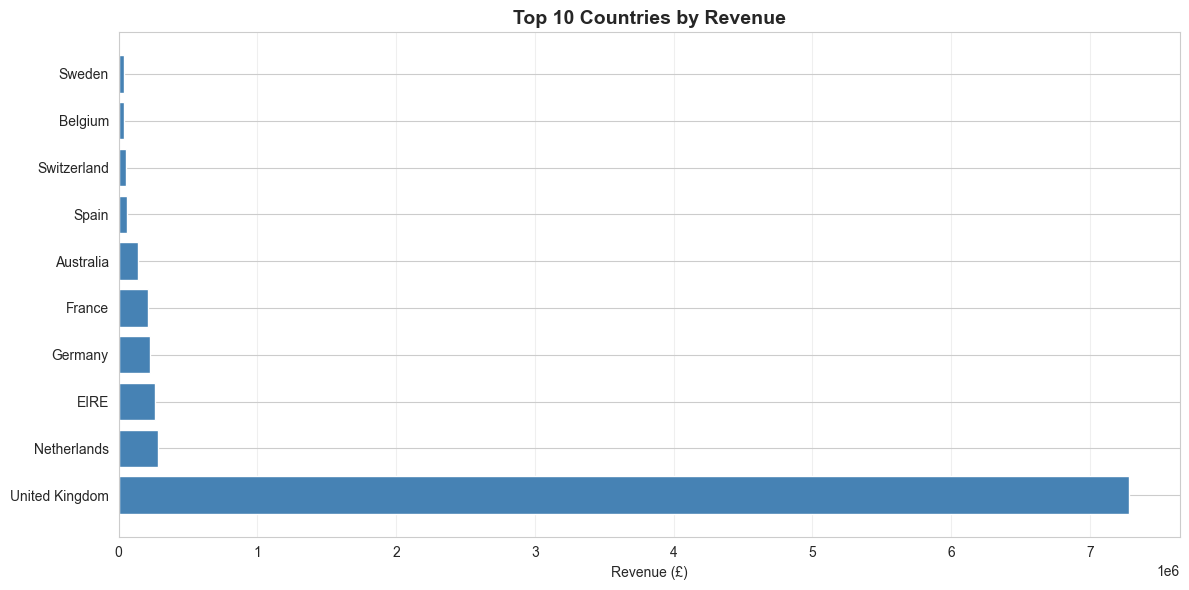


UK represents 82.0% of total revenue


In [11]:
# Top 10 countries
top_countries = df_clean.groupby('Country').agg({
    'Revenue': 'sum',
    'Invoice': 'count'
}).rename(columns={'Invoice': 'Orders'}).sort_values('Revenue', ascending=False).head(10)

print("Top 10 Countries by Revenue:")
print(top_countries)

# Bar chart
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_countries)), top_countries['Revenue'].values, color='steelblue')
plt.yticks(range(len(top_countries)), top_countries.index)
plt.xlabel('Revenue (£)')
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

uk_pct = (top_countries.loc['United Kingdom', 'Revenue'] / df_clean['Revenue'].sum()) * 100
print(f"\nUK represents {uk_pct:.1f}% of total revenue")

Monthly Revenue Summary:
            Revenue
count  1.300000e+01
mean   6.836328e+05
std    2.222110e+05
min    4.460849e+05
25%    5.681013e+05
50%    5.989629e+05
75%    6.773552e+05
max    1.156206e+06


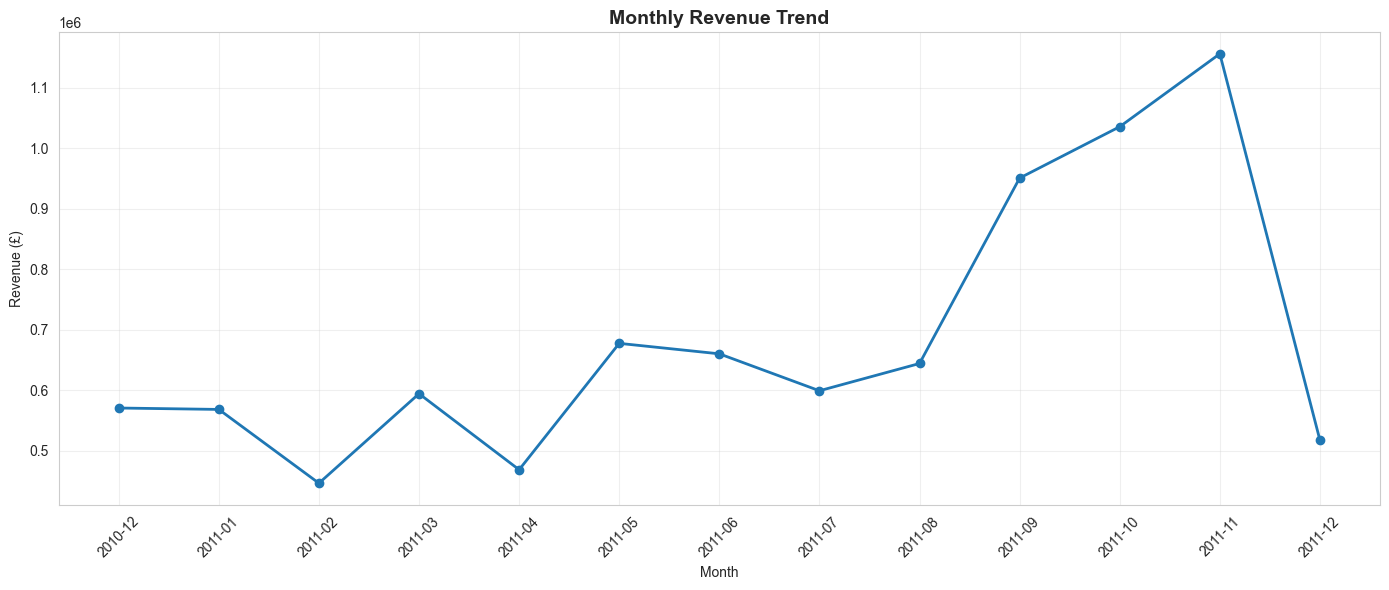


Peak month: 2011-11
Peak revenue: £1,156,205.61


In [10]:
# Sales by month
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

print("Monthly Revenue Summary:")
print(monthly_revenue.describe())

# Create line chart
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], marker='o', linewidth=2, markersize=6)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPeak month: {monthly_revenue.loc[monthly_revenue['Revenue'].idxmax(), 'YearMonth']}")
print(f"Peak revenue: £{monthly_revenue['Revenue'].max():,.2f}")

## Section 1: Temporal Analysis
Understanding sales trends over time

In [9]:
import subprocess
import sys

# Install matplotlib and seaborn
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn"])

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Visualization libraries installed")

✓ Visualization libraries installed


In [8]:
# Parse dates with auto-detection
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')
df_clean = df_clean[df_clean['InvoiceDate'].notna()]  # Remove any unparseable dates

# Create revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Total revenue: £{df_clean['Revenue'].sum():,.2f}")
print(f"Unique customers: {df_clean['Customer ID'].nunique():,}")
print(f"\n✓ Cleaned dataset ready for analysis")

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total revenue: £8,887,226.89
Unique customers: 4,338

✓ Cleaned dataset ready for analysis


In [6]:
# First check actual column names
print("Column names:")
print(df.columns.tolist())

df_clean = df.copy()
df_clean = df_clean[df_clean['Customer ID'].notna()]  # Changed to Customer ID
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
df_clean = df_clean.drop_duplicates()

print(f"\nOriginal: {len(df):,} rows")
print(f"Cleaned: {len(df_clean):,} rows")
print(f"Removed: {len(df) - len(df_clean):,} rows")

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Original: 541,910 rows
Cleaned: 392,693 rows
Removed: 149,217 rows


In [4]:
print("MISSING VALUES:")
null_df = pd.DataFrame({
    'Nulls': df.isnull().sum(),
    'Percent': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_df[null_df['Nulls'] > 0].sort_values('Nulls', ascending=False))

print("\n\nDATA ISSUES:")
print(f"Negative quantities: {(df['Quantity'] < 0).sum():,}")
print(f"Zero/negative prices: {(df['Price'] <= 0).sum():,}")

MISSING VALUES:
              Nulls  Percent
Customer ID  135080    24.93
Description    1454     0.27


DATA ISSUES:
Negative quantities: 10,624
Zero/negative prices: 2,517


In [3]:
df = pd.read_csv(r'C:\projects\retail-data\retail_raw.csv', encoding='latin-1')
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Rows: 541,910
Columns: 8
Memory: 172.1 MB


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print("✓ Libraries loaded")

✓ Libraries loaded
